Background: Lane analyzed extracet data from PEDAP and found this:

> There seems to be more bolus data than basal data.  Here's PtId=3:
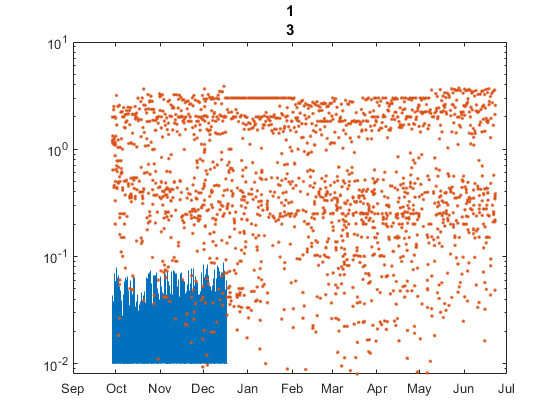
I went back to the raw files and confirmed that for at least PtId, this is the case (looking at starting / ending dates which don't overlap):
PEDAPTandemBolusDelivered.txt
PEDAPTandemBASALRATECHG.txt

In [4]:
##imports
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np
import os
import sys

%matplotlib inline
sys.path.append(os.path.join(os.getcwd(), '..','..'))

from datetime import datetime, timedelta
from studies.studydataset import StudyDataset
from studies.dataset_initializer import initialize_datasets
from src import drawing, cdf, tdd, logger, pandas_helper

import logging
logger = logger.Logger.get_logger("",logging.WARNING)

In [8]:
path = os.path.join(os.getcwd(),'..', '..', 'data', 'raw')
out_path = os.path.join(os.getcwd(),'..', '..', 'data', 'out')
studies = initialize_datasets(path)

[15:38:06] PEDAP matches multiple folders: ['PEDAP Public Dataset - Release 3 - 2024-09-25', 'PEDAP Public Dataset - Release 3 - 2024-09-25.zip']. Using PEDAP Public Dataset - Release 3 - 2024-09-25.
[15:38:06] Unmatched folders:
[15:38:06]   paquet
[15:38:06]   .gitkeep
[15:38:06]   .DS_Store
[15:38:06]   PEDAP Public Dataset - Release 3 - 2024-09-25.zip
[15:38:06]   skip
[15:38:06] Successfully matched studies with folders:
[15:38:06]   PEDAP : /Users/jan/git/nudgebg/babelbetes/notebooks/understand-pedap-dataset/../../data/raw/PEDAP Public Dataset - Release 3 - 2024-09-25


In [9]:
study = studies['PEDAP']
study.extract_basal_event_history()
study.extract_bolus_event_history();

In [10]:
#extract
df_basal = study.extract_basal_event_history()
df_bolus = study.extract_bolus_event_history()
df_glucose = study.extract_cgm_history()
df_basal_raw= study.df_basal


In [11]:
import zipfile
df_visits = None

# Open the zip file and read the specific file
df_visits = pandas_helper.get_df(os.path.join(study.study_path,'Data Files/PEDAPVisitInfo.txt'))
df_visits['VisitDt'] = pd.to_datetime(df_visits['VisitDt'], format='%m/%d/%Y')

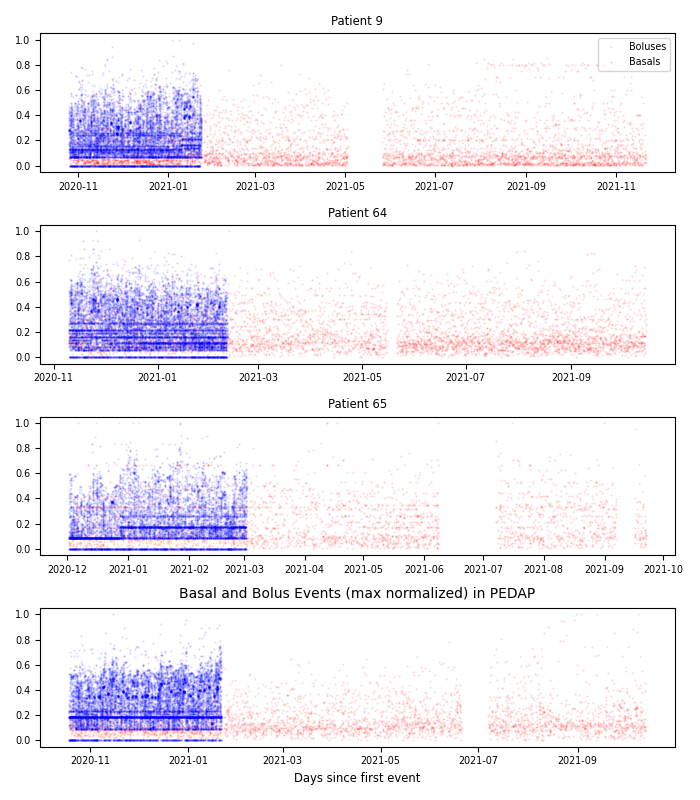

In [ ]:
%matplotlib widget
n = 4
patients = df_bolus['patient_id'].unique()[0:n]
patients = ['9', '64','65','66']
fig, axes = plt.subplots(n, 1, figsize=(7, n*2), sharex=False, sharey=False)
axes = axes.flatten()

format = 'extract'
for i, patient in enumerate(patients):
    basals = df_basal.loc[df_basal.patient_id == patient]
    boluses = df_bolus.loc[df_bolus.patient_id == patient]
    cgms = df_glucose.loc[df_glucose.patient_id == patient]
    basals_raw = df_basal_raw.loc[df_basal_raw.PtID == int(patient)]
    visits = df_visits.loc[df_visits.PtID == int(patient)]
    #get only major weekly visits
    visits = visits.loc[visits.Visit.str.contains('Week')]
    ax = axes[i]

    ax.scatter(boluses.datetime, boluses.bolus.values/boluses.bolus.max(), color=drawing.colors['Bolus'], marker='.', alpha=.1, label='Boluses',s=2)
    ax.scatter(basals.datetime, basals.basal_rate.values/basals.basal_rate.max(), color=drawing.colors['Basal'], alpha=.1, marker='.', label='Basals',s=2)
    #ax.scatter(cgms_days_since_start, cgms.cgm.values/cgms.cgm.max(), color=drawing.colors['CGM'], alpha=1, marker='.', label='CGM',s=2)

    #ax.set_ylabel('Bolus, Basal', fontsize='x-small')
    #twinx.set_ylabel('Basal Rate', fontsize='x-small')
    # cdf.plot_cdf(boluses.datetime, ax=ax, color='white',linewidth=5)
    # cdf.plot_cdf(boluses.datetime, ax=ax, color=drawing.colors['Bolus'],linewidth=2,label='Bolus')
    # cdf.plot_cdf(basals.datetime, ax=ax, color='white',linewidth=5)
    # cdf.plot_cdf(basals.datetime, ax=ax, color=drawing.colors['Basal'],linewidth=2,label='Basal')
    # cdf.plot_cdf(basals_raw.DeviceDtTm, ax=ax, color='magenta',linewidth=2,linestyle='--',marker=None,label='Basal Raw')
    
    #visits
    #ax.vlines(x=visits.VisitDt, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
    #for i,visit in enumerate(visits.itertuples()):
    #    ax.text(visit.VisitDt, 0.5+0.125*(i%4), visit.Visit, fontsize='x-small', color='black', ha='left', va='bottom')
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize='x-small')
    ax.tick_params(axis='y', labelsize='x-small')
    ax.set_title(f'Patient {patient}',fontsize='small')
    #twinx.tick_params(axis='y', labelsize='x-small')
    #ylabel font size small
plt.xlabel('Days since first event', fontsize='small')
plt.tight_layout()
plt.suptitle('Basal and Bolus Events (max normalized) in PEDAP', fontsize='medium', y=1.02)
axes[0].legend(loc='upper right', fontsize='x-small')
#plt.savefig(f'bolus_basal_format={format}.png',dpi=300, bbox_inches='tight')